
# Module 4 – Week 4: Introduction to Differential Equations (RC Circuits)

**Course:** Research – Optimization with Calculus & Differential Equations  
**Module:** Week 4 – Intro to ODEs + RC Circuit Modeling  
**Focus:** First-order linear ODEs; analytical solution via **SymPy**, numerical simulation via **SciPy**.

## Learning Goals
- Recognize and solve a **first-order linear ODE**.  
- Derive and solve the **RC charging/discharging** model: $$\tau \frac{dV_C}{dt} + V_C = V_{in}$$ where $$\tau=RC$$.  
- Compare **closed-form (symbolic)** and **numerical (solve_ivp)** solutions, and interpret parameters $$R, C, \tau$$.

## Problem (Chose **A**)
**A. RC Charging:** For constant input $$V_{in}=V_0$$ and initial condition $$V_C(0)=0$$, solve  
$$\tau \frac{dV_C}{dt} + V_C = V_0.$$


**B. RC Discharging:** For input \(V_{in}=0\) and initial condition \(V_C(0)=V_0\), solve  
$$\tau \frac{dV_C}{dt} + V_C = 0.$$


##### ## 2) SymPy (Symbolic) – Solve the ODE

- Use `sympy.Function`, `sympy.dsolve`, and set initial condition with `ics={...}`.  
- Print a simplified, explicit expression for `V_C(t)`.


In [15]:

# --- SymPy symbolic ODE template ---
import sympy as sp

t = sp.symbols('t', real=True)
V0, tau = sp.symbols('V0 tau', positive=True)
Vc = sp.Function('Vc')

# dVc/dt + (1/tau) Vc = V0 / tau,  Vc(0) = 0
ode = sp.Eq(sp.diff(Vc(t), t) + Vc(t)/tau, V0/tau)
sol = sp.dsolve(ode, ics={Vc(0): 0})

sol


Eq(Vc(t), V0 - V0*exp(-t/tau))


## 3) SciPy (Numerical) – Simulate with `solve_ivp`

- Pick numeric values (e.g., `R=10e3`, `C=1e-6` so `tau = R*C = 0.01 s`, `V0=5`).  
- Simulate on a time span (e.g., 0 to 0.05 s) and plot `Vc(t)`.


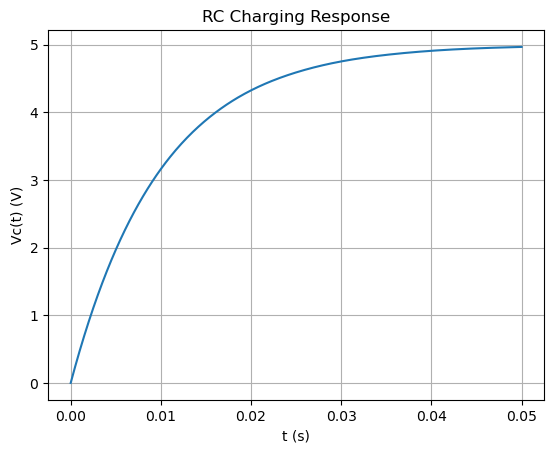

In [16]:

# --- SciPy numerical simulation template ---
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- RC circuit parameters (Charging only) ---
R = 10_000.0      # Ohms
C = 1e-6          # Farads
tau_val = R * C
V0_val = 5.0      # Volts

# --- ODE: dVc/dt = (V0 - Vc)/tau ---
def rc_ode(t, Vc):
    Vin = V0_val
    dVcdt = (Vin - Vc) / tau_val
    return dVcdt

# --- Simulation setup ---
t_span = (0.0, 0.05)
t_eval = np.linspace(t_span[0], t_span[1], 400)
Vc0 = [0.0]   # initial condition for charging: Vc(0) = 0

# --- Numerical solution ---
sol_num = solve_ivp(rc_ode, t_span, Vc0, t_eval=t_eval)

# --- Plot result ---
plt.figure()
plt.plot(sol_num.t, sol_num.y[0])
plt.xlabel("t (s)")
plt.ylabel("Vc(t) (V)")
plt.title("RC Charging Response")
plt.grid(True)
plt.show()


## 4) Brief Comparison & Reflection (3–5 sentences)

- Do the symbolic and numerical solutions agree? Yes, the differential equations agree because Vc(t) lessens as t increases.  
- How does changing \(\tau\) (via \(R\) or \(C\)) affect the response speed? The greater R or C, the greater Tau is, so response speed becomes slower.
- Where do you see this model showing up in real circuits or sensors? This model is found in simple RC circuits with charging and discharging.
